In [ ]:
#Ячейка 1. Импорты
!pip install ultralytics
!pip install onnxruntime
!pip install tensorflow
!pip install gdown
import gdown
from zipfile import ZipFile
from google.colab import files
import cv2
import numpy as np
import json
from ultralytics import YOLO
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 117.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#Ячейка 2. Скачивание датасета

file_id = "1kBH1Tc1lN_Dmk7RVjCRL-Hli0y3DUz3r"
url = f"https://drive.google.com/uc?id={file_id}"
output = "mydataset.zip"

gdown.download(url, output, quiet=False)

with ZipFile("mydataset.zip", 'r') as zip_ref:
    zip_ref.extractall("mydataset")


print(os.listdir("mydataset"))
print(os.listdir("mydataset/mydataset"))
print(os.listdir("mydataset/mydataset/valid"))
with open("mydataset/mydataset/data.yaml", "r") as f:
    print(f.read())

yaml_content = """
train: /content/mydataset/mydataset/train/images
val: /content/mydataset/mydataset/valid/images
test: /content/mydataset/mydataset/test/images

nc: 1
names: ["object"]
"""

with open("mydataset/mydataset/data.yaml", "w") as f:
    f.write(yaml_content)

Downloading...
From (original): https://drive.google.com/uc?id=1kBH1Tc1lN_Dmk7RVjCRL-Hli0y3DUz3r
From (redirected): https://drive.google.com/uc?id=1kBH1Tc1lN_Dmk7RVjCRL-Hli0y3DUz3r&confirm=t&uuid=2bf5b5d1-0c9f-4fd5-af34-a717a23fecc2
To: /content/mydataset.zip
100%|██████████| 6.00G/6.00G [00:22<00:00, 264MB/s]


['mydataset']
['data.yaml', 'train', 'valid', 'test']
['images', 'labels', 'labels.cache']
path: ./mydataset

train: train/images
val: valid/images
test: test/images

nc: 1
names: ['object']


In [ ]:
#НЕ ТРОГАТЬ!
#Ячейка 3. Обучение с нуля
from google.colab import drive
drive.mount('/content/drive')

model = YOLO("yolov8n.pt")

model.train(
    data="/content/mydataset/mydataset/data.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    mosaic=1.0,
    save_period=10,

    project="/content/drive/MyDrive/yolo_runs",
    name="vis_detection"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mydataset/mydataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, m

In [ ]:
#Ячейка 3+. Возобновление обучения с последней точки
from google.colab import drive
drive.mount('/content/drive')
model = YOLO("/content/drive/MyDrive/yolo_runs/vis_detection-5/weights/last.pt")
model.train(
    data="/content/mydataset/mydataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    mosaic=1.0,
    save_period=10,

    project="/content/drive/MyDrive/yolo_runs",
    name="vis_detection"
)

Mounted at /content/drive
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mydataset/mydataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo_runs/vis_detection-5/weights/last.pt, momentum=0.937, mosaic=1.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bce8c1f84a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
model = YOLO("/content/drive/MyDrive/yolo_runs/vis_detection-6/weights/last.pt")
model.train(
    data="/content/mydataset/mydataset/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    mosaic=1.0,
    save_period=10,

    project="/content/drive/MyDrive/yolo_runs",
    name="vis_detection"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mydataset/mydataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bce146b60f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


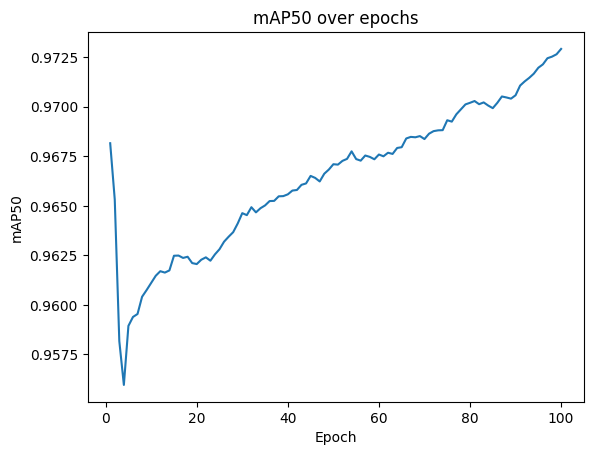

In [ ]:
#Ячейка 4. Графики
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/yolo_runs/vis_detection-6/results.csv")

plt.plot(df["epoch"], df["metrics/mAP50(B)"])
plt.title("mAP50 over epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.show()

In [ ]:
#Ячейка 5. Выгрузка
'''
runs_dir = "runs/detect"
last_train = sorted(os.listdir(runs_dir))[-1]

best_model_path = f"{runs_dir}/{last_train}/weights/best.pt"

print("Best model:", best_model_path)

model = YOLO(best_model_path)

model.export(format="tflite", int8=True)
tflite_path = f"{runs_dir}/{last_train}/weights/best_saved_model/best_int8.tflite"
files.download(tflite_path)
#files.download('runs/detect/train/weights/best_saved_model/best_int8.tflite')
print("PT model:", best_model_path)
print("TFLite model:", tflite_path)
'''
!pip install ultralytics
from ultralytics import YOLO
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

model = YOLO("/content/drive/MyDrive/yolo_runs/vis_detection-6/weights/last.pt")
model.export(format="tflite", int8=True)
tflite_path = f"/content/drive/MyDrive/yolo_runs/vis_detection-6/weights/best_saved_model/best_int8.tflite"
files.download(tflite_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (AMD EPYC 9B45)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo_runs/vis_detection-6/weights/last.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco8.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 3027.1±844.8 MB/s, size: 54.0 KB)
Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 2.1Mit/s 0.0s
WARNING ⚠️ TensorFlow SavedModel: >300 images recommended for INT8 calibration, found 4 im

FileNotFoundError: Cannot find file: /content/drive/MyDrive/yolo_runs/vis_detection-6/weights/best_saved_model/best_int8.tflite

In [4]:
#Ячейка 6. Проверка числа каналов файла .wav
import wave
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

with wave.open(filename, "rb") as audio:
  channels = audio.getnchannels()
  print("Channels:", channels)

Saving 24_04_26_00_35_29_24_04_26_00_35_37_3ch.wav to 24_04_26_00_35_29_24_04_26_00_35_37_3ch (1).wav
Channels: 1
